#### Importando os pacotes

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sma
import regressao_log_lib as rl

In [2]:
# configurando o ambiente de visualização
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

In [24]:
# carregando os dados
df_crm = pd.read_csv('../data/crm_eda_bivariada.csv')
df_crm.head()

,nivel_educacional,estado_civil,faixa_renda_anual,faixa_recencia,canal_preferencial,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,total_filhos,total_compras,total_campanhas_aceitas,Response
0,medio,Solteiro,Alta,Recente,Catalogo,635,88,546,172,88,88,0,25,0,1
1,medio,Solteiro,Media,Recente,Loja,11,1,6,2,1,6,2,6,0,0
2,medio,Casado,Muito_Alta,Muito_Recente,Loja,426,49,127,111,21,42,0,21,0,0
3,medio,Casado,Baixa,Muito_Recente,Loja,11,4,20,10,3,5,1,8,0,0
4,alto,Casado,Alta,Inativo,Loja,173,43,118,46,27,15,1,19,0,0


In [25]:
df_crm.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   nivel_educacional        2240 non-null   str  
 1   estado_civil             2240 non-null   str  
 2   faixa_renda_anual        2216 non-null   str  
 3   faixa_recencia           2240 non-null   str  
 4   canal_preferencial       2240 non-null   str  
 5   MntWines                 2240 non-null   int64
 6   MntFruits                2240 non-null   int64
 7   MntMeatProducts          2240 non-null   int64
 8   MntFishProducts          2240 non-null   int64
 9   MntSweetProducts         2240 non-null   int64
 10  MntGoldProds             2240 non-null   int64
 11  total_filhos             2240 non-null   int64
 12  total_compras            2240 non-null   int64
 13  total_campanhas_aceitas  2240 non-null   int64
 14  Response                 2240 non-null   int64
dtypes: int64(10), s

#### Tratamento valores ausentes

In [26]:
df_crm.isna().sum()

nivel_educacional           0
estado_civil                0
faixa_renda_anual          24
faixa_recencia              0
canal_preferencial          0
MntWines                    0
MntFruits                   0
MntMeatProducts             0
MntFishProducts             0
MntSweetProducts            0
MntGoldProds                0
total_filhos                0
total_compras               0
total_campanhas_aceitas     0
Response                    0
dtype: int64

In [27]:
# preenchendo os valores faltantes da variavel faixa_renda_anual com missing
df_crm['faixa_renda_anual'] = df_crm['faixa_renda_anual'].fillna('missing')

In [7]:
df_crm.isna().sum()

nivel_educacional          0
estado_civil               0
faixa_renda_anual          0
faixa_recencia             0
canal_preferencial         0
MntWines                   0
MntFruits                  0
MntMeatProducts            0
MntFishProducts            0
MntSweetProducts           0
MntGoldProds               0
total_filhos               0
total_compras              0
total_campanhas_aceitas    0
Response                   0
dtype: int64

In [28]:
var_numericas = df_crm.select_dtypes(include=np.number).columns.tolist()
var_numericas

['MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'total_filhos',
 'total_compras',
 'total_campanhas_aceitas',
 'Response']

In [29]:
var_categoricas = df_crm.select_dtypes(include='object').columns.tolist()
var_categoricas

['nivel_educacional',
 'estado_civil',
 'faixa_renda_anual',
 'faixa_recencia',
 'canal_preferencial']

In [30]:
df_dummies = pd.get_dummies(df_crm[var_categoricas], drop_first=True, dtype=int)
df_dummies.head()

,nivel_educacional_baixo,nivel_educacional_medio,estado_civil_Outros,estado_civil_Solteiro,estado_civil_Viúvo,faixa_renda_anual_Baixa,faixa_renda_anual_Media,faixa_renda_anual_Muito_Alta,faixa_renda_anual_missing,faixa_recencia_Muito_Recente,faixa_recencia_Pouco_Ativo,faixa_recencia_Recente,canal_preferencial_Loja,canal_preferencial_Web
0,0,1,0,1,0,0,0,0,0,0,0,1,0,0
1,0,1,0,1,0,0,1,0,0,0,0,1,1,0
2,0,1,0,0,0,0,0,1,0,1,0,0,1,0
3,0,1,0,0,0,1,0,0,0,1,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [31]:
df_odds_ratio = pd.concat([df_crm[var_numericas], df_dummies], axis=1)
df_odds_ratio.head()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,total_filhos,total_compras,total_campanhas_aceitas,Response,nivel_educacional_baixo,nivel_educacional_medio,estado_civil_Outros,estado_civil_Solteiro,estado_civil_Viúvo,faixa_renda_anual_Baixa,faixa_renda_anual_Media,faixa_renda_anual_Muito_Alta,faixa_renda_anual_missing,faixa_recencia_Muito_Recente,faixa_recencia_Pouco_Ativo,faixa_recencia_Recente,canal_preferencial_Loja,canal_preferencial_Web
0,635,88,546,172,88,88,0,25,0,1,0,1,0,1,0,0,0,0,0,0,0,1,0,0
1,11,1,6,2,1,6,2,6,0,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0
2,426,49,127,111,21,42,0,21,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0
3,11,4,20,10,3,5,1,8,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0
4,173,43,118,46,27,15,1,19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [14]:
# salvarndo o dataframe para a modelagem
df_odds_ratio.to_csv('../data/crm_odds_ratio.csv', index=False)

In [32]:
# separando a variável target
y = df_odds_ratio['Response']
X = df_odds_ratio.drop('Response', axis=1)

In [33]:
X

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,total_filhos,total_compras,total_campanhas_aceitas,nivel_educacional_baixo,nivel_educacional_medio,estado_civil_Outros,estado_civil_Solteiro,estado_civil_Viúvo,faixa_renda_anual_Baixa,faixa_renda_anual_Media,faixa_renda_anual_Muito_Alta,faixa_renda_anual_missing,faixa_recencia_Muito_Recente,faixa_recencia_Pouco_Ativo,faixa_recencia_Recente,canal_preferencial_Loja,canal_preferencial_Web
0,635,88,546,172,88,88,0,25,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0
1,11,1,6,2,1,6,2,6,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0
2,426,49,127,111,21,42,0,21,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0
3,11,4,20,10,3,5,1,8,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0
4,173,43,118,46,27,15,1,19,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,709,43,182,42,118,247,1,18,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1
2236,406,0,30,0,0,8,3,22,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1
2237,908,48,217,32,12,24,0,19,1,0,1,1,0,0,0,0,0,0,0,0,0,1,0
2238,428,30,214,80,30,61,1,23,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0


#### Modelo Odds Ratio

In [34]:
X = sma.add_constant(df_odds_ratio[X.columns])
modelo = sma.GLM(df_odds_ratio['Response'],X,family=sma.families.Binomial()).fit()
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               Response   No. Observations:                 2240
Model:                            GLM   Df Residuals:                     2216
Model Family:                Binomial   Df Model:                           23
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -652.41
Date:                ter, 16 jun 2026   Deviance:                       1304.8
Time:                        20:37:44   Pearson chi2:                 2.26e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.2288
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -5.1279      0.621     -8.254      0.000      -6.345      -3.910
MntWines                      9.895e-05      0.000      0.285      0.775      -0.001       0.001
MntFruits                        0.0028      0.002      1.245      0.213      -0.002       0.007
MntMeatProducts                  0.0023      0.000      5.359      0.000       0.001       0.003
MntFishProducts                 -0.0009      0.002     -0.564      0.573      -0.004       0.002
MntSweetProducts                 0.0001      0.002      0.069      0.945      -0.004       0.004
MntGoldProds                     0.0034      0.001      2.318      0.020       0.001       0.006
total_filhos                    -0.1233      0.128     -0.965      0.334      -0.373       0.127
total_compras                    0.0169      0.016      1.060      0.289      -0.014       0.048
total_campanhas_aceitas          1.3882      0.114     12.214      0.000       1.165       1.611
nivel_educacional_baixo         -1.0073      0.288     -3.496      0.000      -1.572      -0.443
nivel_educacional_medio         -0.6541      0.161     -4.055      0.000      -0.970      -0.338
estado_civil_Outros              1.1369      0.216      5.258      0.000       0.713       1.561
estado_civil_Solteiro            1.1120      0.171      6.514      0.000       0.777       1.447
estado_civil_Viúvo               1.2082      0.335      3.602      0.000       0.551       1.866
faixa_renda_anual_Baixa          1.4770      0.320      4.612      0.000       0.849       2.105
faixa_renda_anual_Media          0.9824      0.267      3.674      0.000       0.458       1.506
faixa_renda_anual_Muito_Alta    -0.1353      0.258     -0.524      0.600      -0.642       0.371
faixa_renda_anual_missing       -1.1588      1.133     -1.023      0.306      -3.380       1.062
faixa_recencia_Muito_Recente     2.1501      0.375      5.726      0.000       1.414       2.886
faixa_recencia_Pouco_Ativo       0.6232      0.392      1.590      0.112      -0.145       1.392
faixa_recencia_Recente           1.3659      0.382      3.576      0.000       0.617       2.115
canal_preferencial_Loja         -0.4489      0.267     -1.683      0.092      -0.972       0.074
canal_preferencial_Web           0.5924      0.301      1.971      0.049       0.003       1.181
================================================================================================
"""

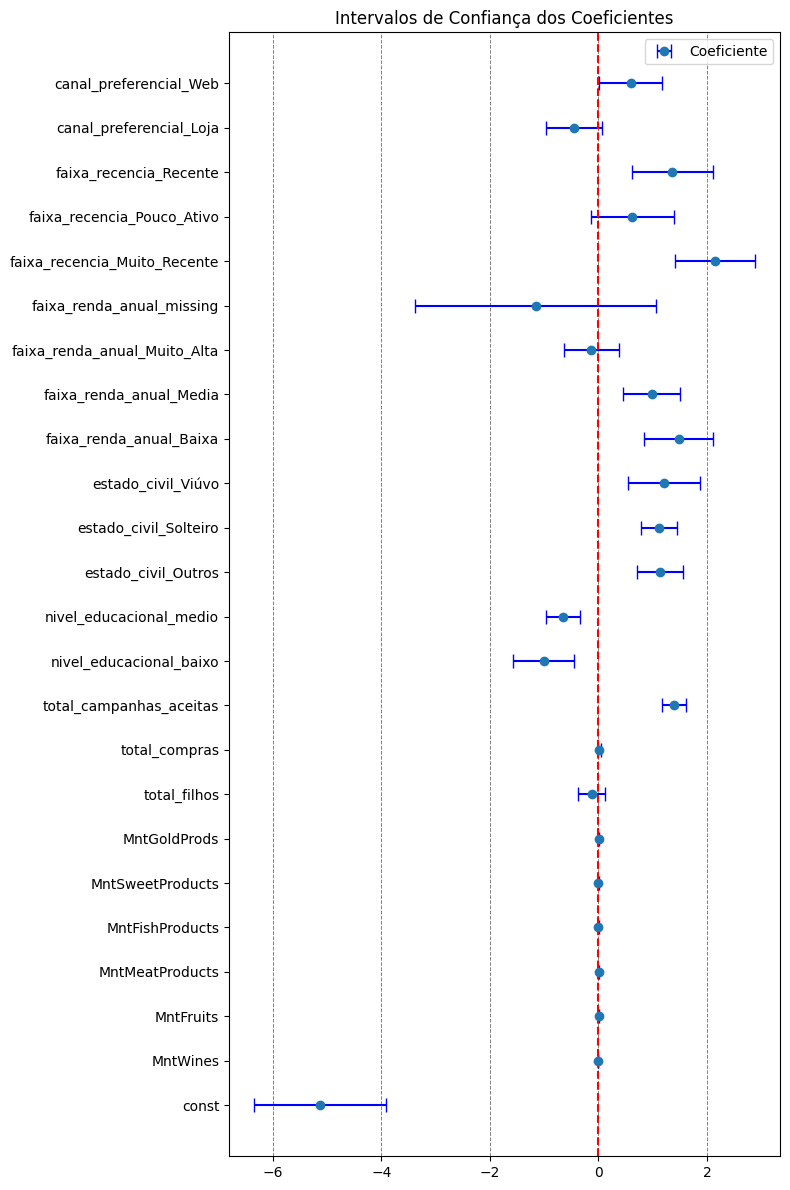

In [35]:
rl.plot_IC95(model=modelo)

In [36]:
def selecionar_pvalor_forward(var_dependente, var_independente, base, signif):
    """   
    Esta função realiza uma seleção forward stepwise com base no p-valor das variáveis independentes.
    A cada passo, adiciona a variável independente com o menor p-valor ao modelo, desde que o p-valor 
    seja menor que o nível de significância especificado.
    
    Parâmetros:
    var_dependente (str): Nome da variável dependente.
    var_independente (list): Lista de variáveis independentes a serem avaliadas.
    base (pd.DataFrame): Conjunto de dados contendo as variáveis dependentes e independentes.
    signif (float): Nível de significância para a inclusão das variáveis (por exemplo, 0.05).
    
    Retorna: 
    pd.DataFrame: DataFrame contendo as variáveis selecionadas e seus respectivos p-valores.
    
    Exemplo de uso:
        >>> import pandas as pd
        >>> df = pd.read_csv('https://raw.githubusercontent.com/Zack1803/Body-Fat-Prediction-Dataset/refs/heads/main/bodyfat.csv')
        >>> colunas_pvalor = selecionar_pvalor_forward(var_dependente='BodyFat', var_independente=df.drop('BodyFat', axis = 1).columns.to_list(), base=df, signif=0.05)
        >>> colunas_pvalor
    
    criada por Mateus Rocha - time ASN.Rocks
    """
    

    preditoras = []
    pvalor_preditoras = []
    Y = base[var_dependente]
    while True and var_independente != []:
        lista_pvalor = []
        lista_variavel = []
        lista_coeficiente = []
        for var in var_independente:
            X = sma.add_constant(base[ [var] +  preditoras ])
            
            modelo = sma.GLM(Y,X,family=sma.families.Binomial()).fit()
            if( preditoras == []):    
                
                pvalor = modelo.pvalues.values[1]
                variavel = modelo.pvalues.index[1]
            
            else:
                
                pvalor = modelo.pvalues.drop(preditoras).values[1]
                variavel = modelo.pvalues.drop(preditoras).index[1]

            lista_pvalor.append(pvalor)
            lista_variavel.append(variavel)      
        
        if( lista_pvalor[ np.argmin(lista_pvalor) ] < signif ):
            preditoras.append( lista_variavel[np.argmin(lista_pvalor)] )
            pvalor_preditoras.append(lista_pvalor[ np.argmin(lista_pvalor) ])
            var_independente.remove( lista_variavel[ np.argmin(lista_pvalor)] )
        else:
            break
    info_final = pd.DataFrame({ 'var': preditoras, 'pvalor': pvalor_preditoras })
    return info_final

In [40]:
# separando a variável target
y = df_odds_ratio['Response']
X = df_odds_ratio.drop('Response', axis=1)

In [41]:
# Selecionar as variáveis com p-valor < 0.05 usando o método forward stepwise
vars_pvalor_fwd = selecionar_pvalor_forward(var_dependente='Response', var_independente=X.columns.tolist(), base=df_odds_ratio, signif=0.05)
vars_pvalor_fwd

,var,pvalor
0,total_campanhas_aceitas,6.891429e-55
1,faixa_recencia_Muito_Recente,9.334525e-17
2,canal_preferencial_Loja,3.394084e-11
3,estado_civil_Solteiro,9.691490e-09
4,MntMeatProducts,8.779731e-07
5,estado_civil_Outros,1.243104e-06
6,faixa_recencia_Recente,2.109559e-05
7,estado_civil_Viúvo,5.337430e-04
8,faixa_renda_anual_Baixa,2.756437e-03
9,faixa_renda_anual_Media,3.948170e-04


In [42]:
X = sma.add_constant(df_odds_ratio[vars_pvalor_fwd['var']])
modelo = sma.GLM(df_odds_ratio['Response'],X,family=sma.families.Binomial()).fit()
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               Response   No. Observations:                 2240
Model:                            GLM   Df Residuals:                     2225
Model Family:                Binomial   Df Model:                           14
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -657.08
Date:                ter, 16 jun 2026   Deviance:                       1314.2
Time:                        20:44:00   Pearson chi2:                 2.22e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.2256
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -4.3563      0.380    -11.471      0.000      -5.101      -3.612
total_campanhas_aceitas          1.3978      0.099     14.175      0.000       1.205       1.591
faixa_recencia_Muito_Recente     1.6589      0.186      8.924      0.000       1.295       2.023
canal_preferencial_Loja         -0.5018      0.263     -1.905      0.057      -1.018       0.015
estado_civil_Solteiro            1.1313      0.170      6.673      0.000       0.799       1.464
MntMeatProducts                  0.0025      0.000      7.056      0.000       0.002       0.003
estado_civil_Outros              1.1446      0.215      5.323      0.000       0.723       1.566
faixa_recencia_Recente           0.8676      0.200      4.347      0.000       0.476       1.259
estado_civil_Viúvo               1.2166      0.334      3.642      0.000       0.562       1.871
faixa_renda_anual_Baixa          1.2499      0.238      5.253      0.000       0.784       1.716
faixa_renda_anual_Media          0.8151      0.215      3.784      0.000       0.393       1.237
nivel_educacional_medio         -0.6666      0.155     -4.309      0.000      -0.970      -0.363
nivel_educacional_baixo         -0.9993      0.280     -3.564      0.000      -1.549      -0.450
MntGoldProds                     0.0038      0.001      2.828      0.005       0.001       0.006
canal_preferencial_Web           0.5849      0.292      2.002      0.045       0.012       1.157
================================================================================================
"""

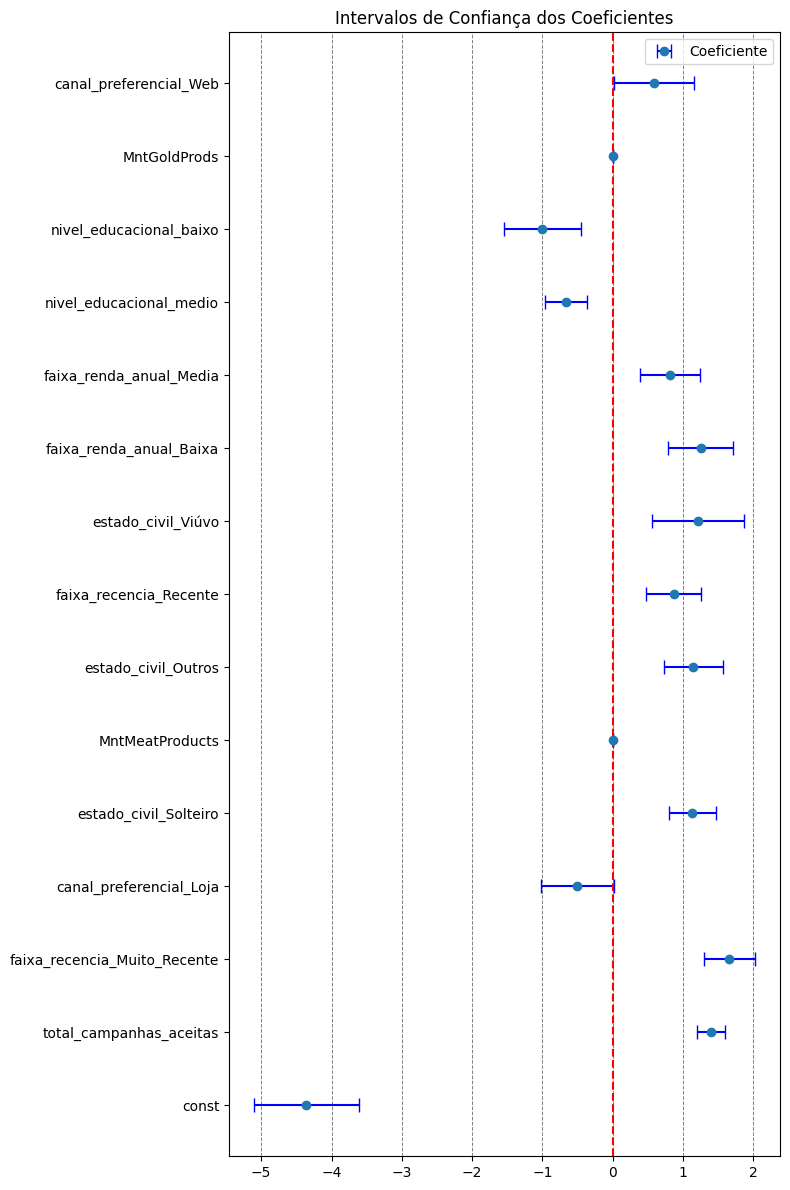

In [43]:
rl.plot_IC95(model=modelo)

In [44]:
#Calculando a exponencial do parâmetro (Odds ratio)
np.exp(modelo.params.sort_index())

MntGoldProds                    1.003837
MntMeatProducts                 1.002484
canal_preferencial_Loja         0.605443
canal_preferencial_Web          1.794743
const                           0.012825
estado_civil_Outros             3.141065
estado_civil_Solteiro           3.099571
estado_civil_Viúvo              3.375532
faixa_recencia_Muito_Recente    5.253469
faixa_recencia_Recente          2.381180
faixa_renda_anual_Baixa         3.490087
faixa_renda_anual_Media         2.259495
nivel_educacional_baixo         0.368128
nivel_educacional_medio         0.513468
total_campanhas_aceitas         4.046378
dtype: float64

In [45]:
# Gerando o valor exponencial dos coeficientes
(np.exp(modelo.params.sort_index())-1)*100

MntGoldProds                      0.383655
MntMeatProducts                   0.248443
canal_preferencial_Loja         -39.455712
canal_preferencial_Web           79.474319
const                           -98.717479
estado_civil_Outros             214.106521
estado_civil_Solteiro           209.957091
estado_civil_Viúvo              237.553169
faixa_recencia_Muito_Recente    425.346903
faixa_recencia_Recente          138.118008
faixa_renda_anual_Baixa         249.008717
faixa_renda_anual_Media         125.949538
nivel_educacional_baixo         -63.187190
nivel_educacional_medio         -48.653201
total_campanhas_aceitas         304.637807
dtype: float64

#### Como interpretar um Odds Ratio
- OR = 1 → não altera a tendencia a resposta a campanhas
- OR > 1 → aumenta a tendencia a resposta a campanhas
- OR < 1 → reduz a tendencia a resposta a campanhas

Lembrando que essa interpretação é mantendo todas as demais variáveis constantes.

#### Qual é a história que os dados nos contam?

- MntGoldProds: Para cada unidade monetária gasta em produtos Gold, as chances aumentam em 0,38% de responder a campanha.
- MntMeatProducts: Para cada unidade monetária gasta em carnes, as chances aumentam em 0,24% de responder a campanha.
- canal_preferencial_Loja: Clientes cujo canal principal é loja, possuem 39,5% menos chances de responder a campanha do que clientes cujo canal principal é catálogo.
- canal_preferencial_Web: Clientes cujo canal principal é Web, possuem 79,5% mais chances de responder a campanha do que clientes cujo canal principal é catálogo.
- estado_civil_Outros: Clientes com estado civil Outros, possuem 214% mais chances de responder a campanha do que clientes casados.
- estado_civil_Solteiro: Clientes solteiros, possuem 209% mais chances de responder a campanha do que clientes casados.
- estado_civil_Viúvo: Clientes viúvos, possuem 237% mais chances de responder a campanha do que clientes casados.
- faixa_recencia_Muito_Recente: Clientes que compraram muito recentemente, possuem 425% mais chances de responder a campanha do que clientes inativos.
- faixa_recencia_Recente: Clientes que compraram recentemente, possuem 138% mais chances de responder a campanha do que clientes inativos.
- faixa_renda_anual_Baixa: Clientes com baixa renda anual, possuem 249% mais chances de responder a campanha do que clientes com alta renda anual.
- faixa_renda_anual_Media: Clientes com média renda anual, possuem 126% mais chances de responder a campanha do que clientes com alta renda anual.
- nivel_educacional_baixo: Clientes com nível educacional baixo, possuem 63% menos chances de responder a campanha do que clientes com nível educacional alto.
- nivel_educacional_medio: Clientes com nível educacional médio, possuem 48% menos chances de responder a campanha do que clientes com nível educacional alto.
- total_campanhas_aceitas: Para cada aumento de uma unidade no número de campanhas aceitas anteriormente, as chances aumentam em 304% de responder a uma nova campanha.

Do ponto de vista de negócio, as variáveis com maiores chances de resposta a campanha foram:
- faixa_recencia_Muito_Recente - 425% : Clientes que compraram recentemente tem maior tendência a responder.
- total_campanhas_aceitas - 304% : Clientes com histórico de aceitação de campanhas anteriores, tem tendência a aceitar uma nova campanha.
- faixa_renda_anual_Baixa - 249% : Clientes tem maior tendência a responder do que clientes de renda alta (talvez a campanha seja mais direcionada a esse público).
- estado_civil_viuvo - 237% : Grupo com maior tendência em relação ao grupo de casados (refêrencia).
- canal_preferencial_Web - 79% : Clientes que preferem o canal digital, respondem melhor as campanhas.

Variáveis que diminuem a chance de resposta:
- canal_preferencial_Loja - 39%
- nivel_educacional_medio - 48%
- nivel_educacional_baixo - 63%

#### Conclusões

O modelo identificou que clientes com histórico de campanhas aceitas, compras recentes e maior utilização do canal digital apresentam maior propensão à adesão da nova campanha. Entre todas as variáveis analisadas, o histórico de campanhas aceitas (OR=4,05) e a recência de compra (OR=5,25 para clientes muito recentes) foram os fatores mais relevantes. Além disso, gastos com produtos premium (Gold) e carnes apresentaram associação positiva com a resposta. Por outro lado, níveis educacionais inferiores estiveram associados a menor probabilidade de resposta.